# 04 — Diffusion-Innovation VAR

Fit DI-VAR on the same rolling calibration residuals. The final chronological portion of those residuals is validation-only; early stopping restores the checkpoint with the lowest validation denoising loss. Test returns remain untouched.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
CACHE = ROOT / 'results/notebook_cache'
CACHE.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

from innovcal.experiments.financial import run_financial_experiment
from innovcal.forecasting.rolling import generate_rolling_var_forecasts

In [2]:
EPOCHS = 300
returns = pd.read_csv(ROOT / 'data/processed/financial_returns.csv', index_col=0).to_numpy()
result = run_financial_experiment(
    returns,
    methods=('diffusion',),
    lags=1,
    n_paths=250,
    seed=123,
    diffusion_options={
        'timesteps': 100,
        'epochs': EPOCHS,
        'hidden_dim': 128,
        'batch_size': 64,
        'validation_fraction': 0.2,
        'early_stopping_patience': 40,
        'verbose': True,
    },
)
history = result.innovation_models['diffusion']['history']
print('Best epoch:', history['best_epoch'])
print('Best validation loss:', history['best_validation_loss'])
display(result.evaluation)

/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


Epoch 0001 | loss = 1.018652 | val = 0.917434
Epoch 0025 | loss = 0.661051 | val = 0.671084
Epoch 0050 | loss = 0.623750 | val = 0.667363
Epoch 0075 | loss = 0.672059 | val = 0.664907
Best epoch: 36
Best validation loss: 0.6607421636581421


,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,...,width_1,coverage_2,width_2,coverage_3,width_3,coverage_4,width_4,nominal_coverage,coverage_error,abs_coverage_error
0,financial,VAR,diffusion,0.927116,0.056497,0.019989,0.008443,0.0749,0.06543,0.021891,...,0.063859,0.944619,0.060331,0.940439,0.062838,0.902821,0.038962,0.9,0.027116,0.027116


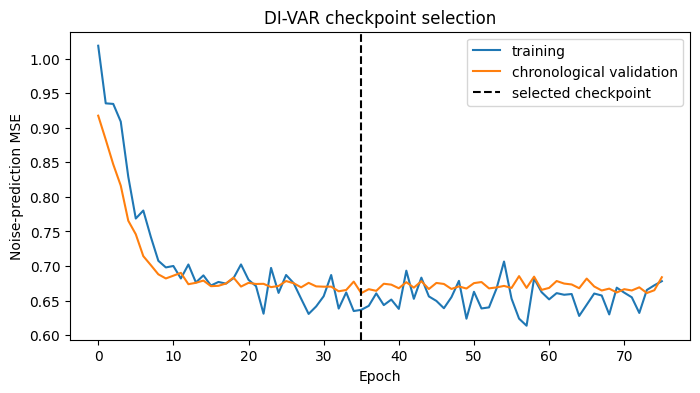

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['loss'], label='training')
ax.plot(history['validation_loss'], label='chronological validation')
if history['best_epoch'] is not None:
    ax.axvline(history['best_epoch'] - 1, color='black', linestyle='--', label='selected checkpoint')
ax.set(xlabel='Epoch', ylabel='Noise-prediction MSE', title='DI-VAR checkpoint selection')
ax.legend()
plt.show()

In [4]:
test_start = len(result.split.train) + len(result.split.calibration)
rolling = generate_rolling_var_forecasts(
    returns,
    test_start=test_start,
    innovation_models=result.innovation_models,
    horizon=20,
    n_paths=250,
    lags=1,
    origin_step=20,
    seed=123,
)
forecast = result.forecasts['diffusion']
np.savez(CACHE / 'forecast_diffusion.npz', **forecast)
np.savez(
    CACHE / 'rolling_diffusion.npz',
    forecasts=rolling.forecasts['diffusion'],
    observations=rolling.observations,
    origins=rolling.origins,
)
result.evaluation.to_csv(CACHE / 'diffusion_evaluation.csv', index=False)

/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


Training and validation loss only select a candidate residual generator. Forecast calibration and robustness are evaluated out of sample in the next notebooks.